# 1. Carga del dataset preprocesado

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(
    "../data/plant1_preprocessed.csv"
)

dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0,0
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0,0
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0,0
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0,0
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0,1


# 2. Eliminación de registros nocturnos


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3157 non-null   str    
 1   AC_POWER             3157 non-null   float64
 2   AMBIENT_TEMPERATURE  3157 non-null   float64
 3   MODULE_TEMPERATURE   3157 non-null   float64
 4   IRRADIATION          3157 non-null   float64
 5   HOUR                 3157 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 148.1 KB


In [4]:
dataset.shape

(3157, 6)

In [5]:
dataset_daylight = dataset[
    dataset["IRRADIATION"] > 0
].copy()

dataset_daylight.shape

(1754, 6)

In [6]:
dataset_daylight.describe()

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
count,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000
mean,12067.930442,27.448244,39.013366,0.414159,11.875143
std,8278.014373,3.228135,11.449517,0.295328,3.793715
min,0.000000,20.398505,18.242308,0.000015,5.000000
25%,4220.645536,25.080542,28.887418,0.139471,9.000000
50%,12459.201488,27.565305,39.604553,0.406717,12.000000
75%,18833.751339,29.741352,47.945945,0.638485,15.000000
max,29150.212499,35.252486,65.545714,1.221652,19.000000


# 3. Selección de variables


In [7]:
y = dataset_daylight["AC_POWER"]

In [8]:
X = dataset_daylight[
    [
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION",
        "HOUR"
    ]
]

In [9]:
X.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
23,24.289211,23.096692,0.000863,5
24,24.088446,22.206757,0.005887,6
25,24.011635,22.353459,0.022282,6
26,23.976731,22.893282,0.049410,6
27,24.218990,24.442444,0.095394,6


In [11]:
y.head()

23       0.000000
24      90.929167
25     593.338690
26    1480.194643
27    2790.448214
Name: AC_POWER, dtype: float64

In [12]:
print("X:", X.shape)
print("y:", y.shape)

X: (1754, 4)
y: (1754,)


# 4. División entrenamiento-prueba interna (70%/30% de Plant 1)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1227, 4)
X_test: (527, 4)
y_train: (1227,)
y_test: (527,)


# 5. Entrenamiento del modelo Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [16]:
y_pred = rf.predict(X_test)

# 6. Evaluación del modelo

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 486.2249330621819
RMSE: 783.6799667794394
R²: 0.9909719689206529


# 7. Visualización de resultados

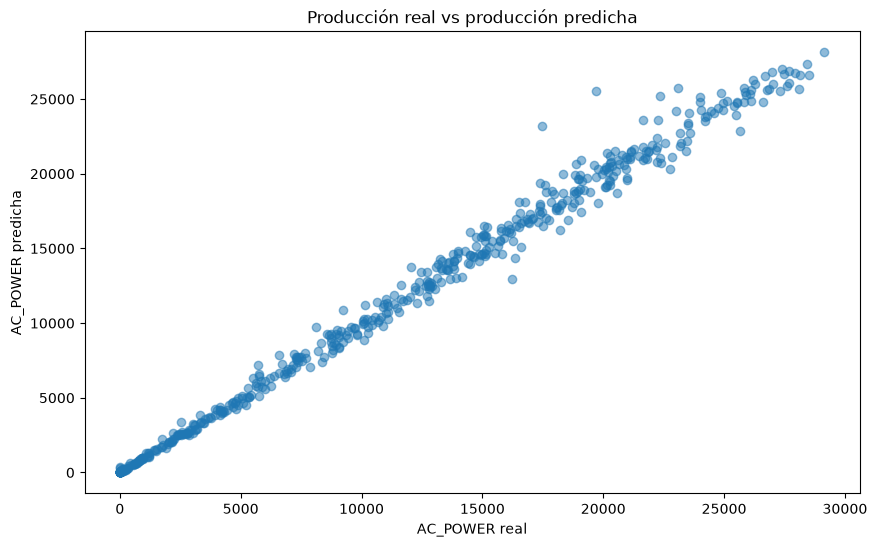

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("AC_POWER real")
plt.ylabel("AC_POWER predicha")
plt.title("Producción real vs producción predicha")

plt.show()

In [19]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
2,IRRADIATION,0.994110
1,MODULE_TEMPERATURE,0.002507
0,AMBIENT_TEMPERATURE,0.002082
3,HOUR,0.001300


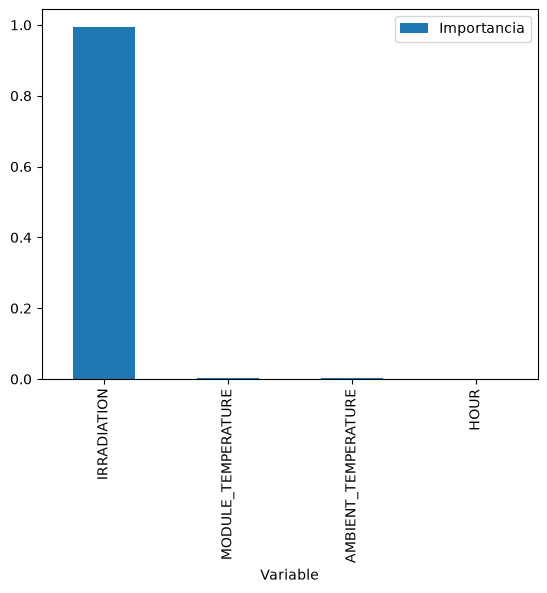

In [20]:
feature_importance.sort_values(
    by="Importancia",
    ascending=False
).plot(
    x="Variable",
    y="Importancia",
    kind="bar"
)

plt.show()




# 8. Exportación del modelo

In [28]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_plant1.pkl"
)

['../models/random_forest_plant1.pkl']

# 9. Validación externa con Plant 2

In [21]:
plant2 = pd.read_csv(
    "../data/plant2_preprocessed.csv"
)

plant2.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
0,2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0,0
1,2020-05-15 00:15:00,0.0,26.880811,24.421869,0.0,0
2,2020-05-15 00:30:00,0.0,26.682055,24.427290,0.0,0
3,2020-05-15 00:45:00,0.0,26.500589,24.420678,0.0,0
4,2020-05-15 01:00:00,0.0,26.596148,25.088210,0.0,1


In [22]:
plant2_daylight = plant2[
    plant2["IRRADIATION"] > 0
].copy()

print(plant2_daylight.shape)

(1862, 6)


In [23]:
X2 = plant2_daylight[
    [
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION",
        "HOUR"
    ]
]

y2 = plant2_daylight["AC_POWER"]

In [24]:
y2_pred = rf.predict(X2)

In [25]:
mae2 = mean_absolute_error(y2, y2_pred)

rmse2 = np.sqrt(
    mean_squared_error(y2, y2_pred)
)

r2_2 = r2_score(y2, y2_pred)

print("MAE:", mae2)
print("RMSE:", rmse2)
print("R²:", r2_2)

MAE: 3207.813310049959
RMSE: 5549.028437325891
R²: 0.16451418260414263


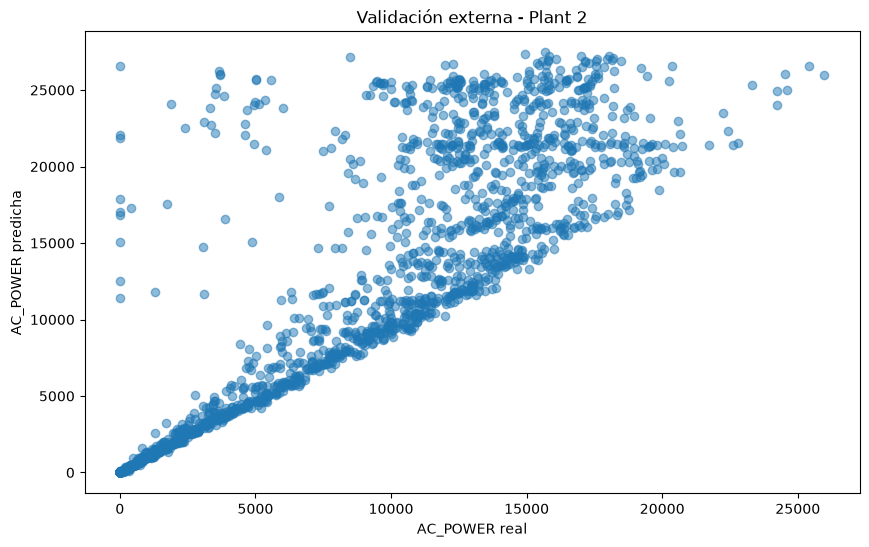

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    y2,
    y2_pred,
    alpha=0.5
)

plt.xlabel("AC_POWER real")
plt.ylabel("AC_POWER predicha")
plt.title("Validación externa - Plant 2")

plt.show()

In [27]:
plant2_daylight["AC_POWER"].describe()

count     1862.000000
mean      8772.292980
std       6072.451589
min          0.000000
25%       2748.819286
50%       9703.754048
75%      13748.358333
max      25979.760476
Name: AC_POWER, dtype: float64